<a href="https://colab.research.google.com/github/imid12/AI-Portfolio-Iman-Haamid/blob/main/md_iman_haamid_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Week 1
Initializing the environment ✨


In [1]:
# This is to reload the contents every time.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import shutil

# 1. Define Paths
ROOT = '/content/drive/MyDrive/ITAI_2376_Project/'
# Path where you store your keys in Google Drive
drive_config_dir = '/content/drive/MyDrive/ITAI_Midterm_Project/'

# Define local destinations
os.makedirs('config', exist_ok=True)

# List of files to sync (Source Path, Destination Path)
files_to_sync = [
    (os.path.join(drive_config_dir, 'credentials.json'), 'config/credentials.json'),
    (os.path.join(drive_config_dir, 'crewai-financial-agent-567d9487f274.json'), 'config/service_account.json')
]

# 2. Execute Copy
for source, destination in files_to_sync:
    if os.path.exists(source):
        shutil.copy(source, destination)
        print(f"✅ Synced: {os.path.basename(source)} -> {destination}")
    else:
        print(f"🔴 MISSING IN DRIVE: {source}")

print("\n🚀 Config directory is ready for the Accountant Agent.")

✅ Synced: credentials.json -> config/credentials.json
✅ Synced: crewai-financial-agent-567d9487f274.json -> config/service_account.json

🚀 Config directory is ready for the Accountant Agent.


In [3]:
!pip install crewai langchain_community langchain_google_genai
# Uninstall and reinstall crewai-tools to ensure the latest version and correct modules
!pip uninstall -y crewai-tools
!pip install crewai-tools --upgrade
!pip install 'crewai[tools]'
import crewai
print(f"CrewAI version: {crewai.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 7.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opentelemetry-exporter-otlp-proto-grpc to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of opentelemetry-exporter-otlp-proto-grpc to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of typer to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━

In [4]:
from crewai_tools import TXTSearchTool, DirectoryReadTool, FileReadTool

# Since you are targeting a specific Google Sheet for your budget data:
# Replace 'YOUR_SPREADSHEET_ID' with the long ID in your browser URL
# Example: https://docs.google.com/spreadsheets/d/1ABC123...
#target_spreadsheet_id = '1gLsexPjPJa9N7ngyToQh7awEYX2k7bJvvnBiiuNx8RI'
target_spreadsheet_id = '1KO7CpdOoL30cM73kg-6jiLkyz2wzgyR6IfdqcTV-NFI'

# Initialize the tool
from crewai_tools import ScrapeElementFromWebsiteTool, PDFSearchTool

# Let's use a custom functional tool for maximum control over your LSTM formatting
from crewai.tools import tool

@tool("read_spending_sheet")
def read_spending_sheet() -> str:
    """Reads the Historical Spending Google Sheet and returns the last 6 months
    of grocery, gas, and utility data as a raw string."""
    # This is where your service account logic lives
    import gspread
    from google.oauth2.service_account import Credentials

    scopes = ['https://www.googleapis.com/auth/spreadsheets.readonly']
    creds = Credentials.from_service_account_file('/content/config/service_account.json', scopes=scopes)
    client = gspread.authorize(creds)

    sheet = client.open_by_key(target_spreadsheet_id).sheet1
    data = sheet.get_all_records()
    return str(data[-180:]) # Returns approx last 6 months if daily, or adjust as needed

###**Week 1**
Setting up Gemini API Key. Because I am using Gemini 1.5 Pro as the Orchestrator.


1.   API Key Management
2.   Library Integration
3.   LLM Initialization



In [5]:
@tool("get_upcoming_bills")
def get_upcoming_bills() -> str:
    """
    Retrieves the next 5 events from the user's calendar.
    Useful for identifying scheduled bill payments and recurring expenses.
    """
    from googleapiclient.discovery import build
    from google.oauth2.service_account import Credentials

    creds = Credentials.from_service_account_file('config/service_account.json',
                                                   scopes=['https://www.googleapis.com/auth/calendar.readonly'])
    service = build('calendar', 'v3', credentials=creds)

    events_result = service.events().list(
        calendarId='dimaah@gmail.com',
        timeMin='2026-04-12T00:00:00Z',
        maxResults=5
    ).execute()

    events = events_result.get('items', [])
    return "\n".join([f"Event: {e['summary']} on {e.get('start').get('date') or e.get('start').get('dateTime')}" for e in events])

In [7]:
import os
from crewai import Agent
from google.colab import userdata
import gspread
from google.colab import auth
from google.auth import compute_engine

# Import your custom tool defined in cell wfNQhMkCbSEt
from __main__ import read_spending_sheet

# 1. Standard environment setup
os.environ["GEMINI_API_KEY"] = userdata.get('GEMINI_API_KEY')
os.environ["OPENAI_API_KEY"] = "dummy_key" # Keep this to bypass CrewAI validation

# Authenticate gspread for use with the tool
auth.authenticate_user()
gc = gspread.authorize(compute_engine.Credentials())

accountant = Agent(
    role="Financial Accountant",
    goal="Consolidate spending data and match recurring bills to calendar events",
    backstory="""You are a meticulous Financial Chief of Staff based in Pearland.
    You excel at cross-referencing bank statements with calendar reminders to ensure
    all obligations are met.""",
    verbose=True,
    allow_delegation=False,
    llm="gemini/gemini-3.1-flash-lite-preview",
    tools=[read_spending_sheet, get_upcoming_bills] # Both tools now available!
)

Authenticating a Google account within a Google Colab environment to interact specifically with the Google Calendar API.

In [8]:
from crewai import Task  # <--- KEEP THIS!

# Now you define the specific task for your ITAI 2376 project
read_budget_task = Task(
    description="""Access the 'Historical Spending' Google Sheet.
    1. Extract groceries, gas, and utilities for the last 6 months.
    2. Handle missing values using linear interpolation.
    3. Normalize the data between 0 and 1.
    4. Format as a time-series JSON array for LSTM input.""",
    expected_output="A normalized JSON array of monthly spending sequences.",
    agent=accountant,
    # Optional: Save the results so you can inspect them for your midterm report
    output_file="data/raw/normalized_spending.json"
)

In [9]:
from google import genai
import os
from google.colab import userdata

# Initialize the client using your Gemini API Key
client = genai.Client(api_key=userdata.get('GEMINI_API_KEY'))

print(f"{'Model Name':<40} | {'Supported Methods'}")
print("-" * 80)

# Retrieve and list all base models
models = client.models.list()

for model in models:
    # Filter for Gemini models to keep the output tidy
    if 'gemini' in model.name.lower():
        # Safely get the 'supported_generation_methods' attribute
        # If the attribute does not exist, it will default to an empty list
        methods = getattr(model, 'supported_generation_methods', [])
        methods_str = ", ".join(methods) if methods else "N/A"
        print(f"{model.name:<40} | {methods_str}")

Model Name                               | Supported Methods
--------------------------------------------------------------------------------
models/gemini-2.5-flash                  | N/A
models/gemini-2.5-pro                    | N/A
models/gemini-2.0-flash                  | N/A
models/gemini-2.0-flash-001              | N/A
models/gemini-2.0-flash-lite-001         | N/A
models/gemini-2.0-flash-lite             | N/A
models/gemini-2.5-flash-preview-tts      | N/A
models/gemini-2.5-pro-preview-tts        | N/A
models/gemini-flash-latest               | N/A
models/gemini-flash-lite-latest          | N/A
models/gemini-pro-latest                 | N/A
models/gemini-2.5-flash-lite             | N/A
models/gemini-2.5-flash-image            | N/A
models/gemini-3-pro-preview              | N/A
models/gemini-3-flash-preview            | N/A
models/gemini-3.1-pro-preview            | N/A
models/gemini-3.1-pro-preview-customtools | N/A
models/gemini-3.1-flash-lite-preview     | N/A
models/gemi

In [10]:
import os
import shutil
from crewai import Crew, Process

# Assemble the financial crew
itai_midterm_crew = Crew(
    agents=[accountant],
    tasks=[read_budget_task],
    process=Process.sequential, # Tasks are completed one after the other
    verbose=True
)

# Define service account file paths for verification
service_account_source = '/content/drive/MyDrive/ITAI_Midterm_Project/crewai-financial-agent-567d9487f274.json'
service_account_dest = 'config/service_account.json'

# Ensure the config directory exists
os.makedirs('config', exist_ok=True)

# Verify and re-copy the service account file if it's missing or if this step needs to be robust
if not os.path.exists(service_account_dest):
    if os.path.exists(service_account_source):
        shutil.copy(service_account_source, service_account_dest)
        print(f"✅ Re-synced: {os.path.basename(service_account_source)} -> {service_account_dest}")
    else:
        print(f"🔴 CRITICAL ERROR: Service account file missing from Drive: {service_account_source}")
        # Optionally, raise an error or exit if the file is absolutely necessary
        # raise FileNotFoundError(f"Service account file not found: {service_account_source}")

# Start the work!
print("### 🏗️ Starting the Financial Consolidation Process...")
try:
    result = itai_midterm_crew.kickoff()

    # Save the output to your new directory structure
    os.makedirs('data/raw', exist_ok=True) # Ensure data/raw exists
    with open('data/raw/budget_consolidation_report.md', 'w') as f:
        f.write(str(result))

    print("\n\n✅ Task complete. Report saved to data/raw/")
except Exception as e:
    print(f"\n\n❌ CrewAI Kickoff failed: {e}")
    # You might want to log the full traceback here for debugging


### 🏗️ Starting the Financial Consolidation Process...


╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 3f92edd8-b0dd-4c35-983b-8151e469baa2                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: Access the 'Historical Spending' Google Sheet.                                                           │
│      1. Extract groceries, gas, and utilities for the last 6 months.                                            │
│      2. Handle missing values using linear interpolation.                                                       │
│      3. Normalize the data between 0 and 1.                                                                     │
│      4. Format as a time-series JSON array for LSTM input.                                                      │
│  ID: ad690784-c99f-418a-9dc3-894c011614c9                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Financial Accountant                                                                                    │
│                                                                                                                 │
│  Task: Access the 'Historical Spending' Google Sheet.                                                           │
│      1. Extract groceries, gas, and utilities for the last 6 months.                                            │
│      2. Handle missing values using linear interpolation.                                                       │
│      3. Normalize the data between 0 and 1.                                                                     │
│      4. Format as a time-series JSON array for LSTM input.                                                      │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────── 🔧 Tool Execution Started (#1) ─────────────────────────────────────────╮
│                                                                                                                 │
│  Tool: read_spending_sheet                                                                                      │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭────────────────────────────────────────────── 🔧 Tool Error (#2) ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Tool Failed                                                                                                    │
│  Tool: read_spending_sheet                                                                                      │
│  Iteration: 2                                                                                                   │
│  Attempt: 0                                                                                                     │
│  Error:                                                                                                         │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Financial Accountant                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  Due to the inability to retrieve data from the 'Historical Spending' Google Sheet, it is impossible to         │
│  perform the requested linear interpolation, normalization, or formatting for an LSTM input.                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: Access the 'Historical Spending' Google Sheet.                                                           │
│      1. Extract groceries, gas, and utilities for the last 6 months.                                            │
│      2. Handle missing values using linear interpolation.                                                       │
│      3. Normalize the data between 0 and 1.                                                                     │
│      4. Format as a time-series JSON array for LSTM input.                                                      │
│  Agent: Financial Accountant                                                                                    │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 3f92edd8-b0dd-4c35-983b-8151e469baa2                                                                       │
│  Final Output: Due to the inability to retrieve data from the 'Historical Spending' Google Sheet, it is         │
│  impossible to perform the requested linear interpolation, normalization, or formatting for an LSTM input.      │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯



✅ Task complete. Report saved to data/raw/


In [11]:
from googleapiclient.discovery import build
from google.oauth2.service_account import Credentials
import datetime

# 1. Setup credentials using the local path we created
SERVICE_ACCOUNT_FILE = 'config/service_account.json'
SCOPES = ['https://www.googleapis.com/auth/calendar.readonly']

try:
    creds = Credentials.from_service_account_file(SERVICE_ACCOUNT_FILE, scopes=SCOPES)
    # 2. Initialize the 'service' object
    service = build('calendar', 'v3', credentials=creds)

    # 3. Your test block
    print("### 📅 Testing Calendar Connection...")
    events_result = service.events().list(
        calendarId='dimaah@gmail.com',
        timeMin='2026-04-12T00:00:00Z',
        maxResults=5
    ).execute()

    events = events_result.get('items', [])
    if not events:
        print("✅ Connection works, but no events found. (Check sharing settings!)")
    for event in events:
        print(f"🌟 Found Event: {event['summary']}")

except Exception as e:
    print(f"🔴 Service Account Error: {e}")

### 📅 Testing Calendar Connection...
🌟 Found Event: Weekly washing of clothes
🌟 Found Event: Xfinity Bill
🌟 Found Event: Chase Bill
🌟 Found Event: Capital One Bill


In [12]:
#consolidation_task = Task(
    description="""
    1. Use 'read_spending_sheet' to get the last 6 months of spending data.
    2. Use 'get_upcoming_bills' to identify which bills (Xfinity, Chase, etc.) are due this week.
    3. Match the upcoming calendar events to the historical spending categories.
    4. Provide a final JSON report that includes:
       - The predicted cost of each upcoming bill based on historical averages.
       - A 'status' for each bill (e.g., 'Expected', 'Anomalous', or 'Missing').
    """,
    expected_output="A structured JSON report matching calendar bills to spending trends.",
    agent=accountant,
    output_file="data/raw/master_consolidation_report.json"
)

In [13]:
itai_midterm_crew = Crew(
    agents=[accountant],
    tasks=[consolidation_task],
    verbose=True
)

result = itai_midterm_crew.kickoff()

╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 1d9c37ca-223a-401a-8561-d80234c8c51a                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name:                                                                                                          │
│      1. Use 'read_spending_sheet' to get the last 6 months of spending data.                                    │
│      2. Use 'get_upcoming_bills' to identify which bills (Xfinity, Chase, etc.) are due this week.              │
│      3. Match the upcoming calendar events to the historical spending categories.                               │
│      4. Provide a final JSON report that includes:                                                              │
│         - The predicted cost of each upcoming bill based on historical averages.                                │
│         - A 'status' for each bill (e.g., 'Expected', 'Anomalous', or 'Missing').                               │
│                                                                                                                 │
│  ID: 22c2d987-6464-4446-a247-fed1ea7617af                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Financial Accountant                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│      1. Use 'read_spending_sheet' to get the last 6 months of spending data.                                    │
│      2. Use 'get_upcoming_bills' to identify which bills (Xfinity, Chase, etc.) are due this week.              │
│      3. Match the upcoming calendar events to the historical spending categories.                               │
│      4. Provide a final JSON report that includes:                                                              │
│         - The predicted cost of each upcoming bill based on historical averages.                                │
│         - A 'status' for each bill (e.g., 'Expected', 'Anomalous', or 'Missing').                               │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────── 🔧 Tool Execution Started (#3) ─────────────────────────────────────────╮
│                                                                                                                 │
│  Tool: read_spending_sheet                                                                                      │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Tool read_spending_sheet executed with result: Error executing tool: ...


...

╭─────────────────────────────────────── ✅ Tool Execution Completed (#2) ────────────────────────────────────────╮
│                                                                                                                 │
│  Tool Completed                                                                                                 │
│  Tool: get_upcoming_bills                                                                                       │
│  Output: Event: Weekly washing of clothes on 2015-06-07T08:00:00-05:00                                          │
│  Event: Xfinity Bill on 2019-04-14                                                                              │
│  Event: Chase Bill on 2019-04-05                                                                                │
│  Event: Capital One Bill on 2019-04-23                                                                          │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Financial Accountant                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "report_date": "2019-04-03",                                                                                 │
│    "upcoming_bills_analysis": [                                                                                 │
│      {                                                                                                          │
│        "bill_name": "Chase Bill",                                                                               │
│        "due_date": "2019-04-05",                                                                                │
│        "predicted_cost": "N/A",                                                                                 │
│        "status": "Missing",                                                                                     │
│        "note": "Unable to retrieve historical spending data to calculate average."                              │
│      },                                                                                                         │
│      {                                                                                                          │
│        "bill_name": "Xfinity Bill",                                                                             │
│        "due_date": "2019-04-14",                                                                                │
│        "predicted_cost": "N/A",                                                                                 │
│        "status": "Missing",                                                                                     │
│        "note": "Unable to retrieve historical spending data to calculate average."                              │
│      },                                                                                                         │
│      {                                                                                                          │
│        "bill_name": "Capital One Bill",                                                                         │
│        "due_date": "2019-04-23",                                                                                │
│        "predicted_cost": "N/A",                                                                                 │
│        "status": "Missing",                                                                                     │
│        "note": "Unable to retrieve historical spending data to calculate average."                              │
│      }                                                                                                          │
│    ],                                                                                                           │
│    "error": "The 'read_spending_sheet' tool failed to return data, preventing the calculation of historical     │
│  averages and status classification."                                                                           │
│  }                                                                                                              │
│                                                                                                                 │
╰────────────────────────────────────────────────────────

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name:                                                                                                          │
│      1. Use 'read_spending_sheet' to get the last 6 months of spending data.                                    │
│      2. Use 'get_upcoming_bills' to identify which bills (Xfinity, Chase, etc.) are due this week.              │
│      3. Match the upcoming calendar events to the historical spending categories.                               │
│      4. Provide a final JSON report that includes:                                                              │
│         - The predicted cost of each upcoming bill based on historical averages.                                │
│         - A 'status' for each bill (e.g., 'Expected', 'Anomalous', or 'Missing').                               │
│                                                                                                                 │
│  Agent: Financial Accountant                                                                                    │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 1d9c37ca-223a-401a-8561-d80234c8c51a                                                                       │
│  Final Output: {                                                                                                │
│    "report_date": "2019-04-03",                                                                                 │
│    "upcoming_bills_analysis": [                                                                                 │
│      {                                                                                                          │
│        "bill_name": "Chase Bill",                                                                               │
│        "due_date": "2019-04-05",                                                                                │
│        "predicted_cost": "N/A",                                                                                 │
│        "status": "Missing",                                                                                     │
│        "note": "Unable to retrieve historical spending data to calculate average."                              │
│      },                                                                                                         │
│      {                                                                                                          │
│        "bill_name": "Xfinity Bill",                                                                             │
│        "due_date": "2019-04-14",                                                                                │
│        "predicted_cost": "N/A",                                                                                 │
│        "status": "Missing",                                                                                     │
│        "note": "Unable to retrieve historical spending data to calculate average."                              │
│      },                                                                                                         │
│      {                                                                                                          │
│        "bill_name": "Capital One Bill",                                                                         │
│        "due_date": "2019-04-23",                                                                                │
│        "predicted_cost": "N/A",                                                                                 │
│        "status": "Missing",                                                                                     │
│        "note": "Unable to retrieve historical spending data to calculate average."                              │
│      }                                                                                                          │
│    ],                                                                                                           │
│    "error": "The 'read_spending_sheet' tool failed to return data, preventing the calculation of historical     │
│  averages and status classification."                                                                           │
│  }                                                                                                              │
│                                                                                                                 │
│                                                       



╭────────────────────────── Tracing Preference Saved ──────────────────────────╮
│                                                                              │
│  Info: Tracing has been disabled.                                            │
│                                                                              │
│  Your preference has been saved. Future Crew/Flow executions will not        │
│  collect traces.                                                             │
│                                                                              │
│  To enable tracing later, do any one of these:                               │
│  • Set tracing=True in your Crew/Flow code                                   │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file               │
│  • Run: crewai traces enable                                                 │
│                                                                              │
╰─────────────────────────

In [14]:
import os
import shutil

# 1. Define the source (Drive) and destination (Local Project)
source_path = '/content/drive/MyDrive/ITAI_Midterm_Project/data/raw/ibkr_trades_april.csv'
dest_dir = 'data/raw'
dest_path = os.path.join(dest_dir, 'ibkr_trades_april.csv')

# 2. Create the local data/raw directory if it doesn't exist
os.makedirs(dest_dir, exist_ok=True)

# 3. Copy the file
try:
    if os.path.exists(source_path):
        shutil.copy(source_path, dest_path)
        print(f"✅ Success! File copied to: {dest_path}")

        # Verify it works with your specific Tab-Separated format
        import pandas as pd
        test_df = pd.read_csv(dest_path, sep='\t')
        print("\nPreview of Local File:")
        print(test_df.head(2))
    else:
        print(f"🔴 Error: Source file not found at {source_path}")
        print("Make sure you have mounted your Google Drive first using: drive.mount('/content/drive')")
except Exception as e:
    print(f"🔴 An error occurred: {e}")

✅ Success! File copied to: data/raw/ibkr_trades_april.csv

Preview of Local File:
             Statement,Header,Field Name,Field Value
0           Statement,Data,Title,Transaction History
1  Statement,Data,Period,"March 10, 2026 - April ...


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
import numpy as np # Ensure numpy is imported
from sklearn.preprocessing import MinMaxScaler # Ensure MinMaxScaler is imported
import pandas as pd # Ensure pandas is imported
import os

# --- Start of file generation and re-initialization for clarity and robustness ---
# This block ensures 'daily_liquidity.csv' is created if it doesn't exist, mirroring cell PXeCHpb9aBNR's functionality.

# Create the full directory structure again just to be safe
folders = ['data/raw', 'data/processed', 'data/lstm_ready', 'models/lstm']
for folder in folders:
    os.makedirs(folder, exist_ok=True)

# 1. Load your original uploaded file (adjust name if needed)
# The file was moved to 'data/raw/ibkr_trades_april.csv' in a previous step
raw_file = 'data/raw/ibkr_trades_april.csv'

# Check if the raw_file exists, otherwise mock a DataFrame for execution.
# In a real scenario, you'd ensure the file is uploaded or generated upstream.
if not os.path.exists(raw_file):
    print(f"⚠️ Warning: {raw_file} not found. Creating a dummy DataFrame for demonstration.")
    # Create a dummy DataFrame if the file doesn't exist
    data_mock = {
        'Date': pd.to_datetime(pd.date_range(start='2025-03-01', periods=20, freq='D')),
        'Net Amount': np.random.rand(20) * 100 - 50 # Example: some positive and negative values
    }
    df = pd.DataFrame(data_mock)
    df['Account'] = 'DummyAccount' # Add a dummy account column for sanitization step
else:
    df = pd.read_csv(raw_file, skiprows=9)


# 2. Sanitize (Remove Account info)
if 'Account' in df.columns:
    df = df.drop(columns=['Account'])
df.to_csv('data/processed/sanitized_trades.csv', index=False)

# 3. Create Daily Liquidity for LSTM
df['Date'] = pd.to_datetime(df['Date'])
daily_cashflow = df.groupby('Date')['Net Amount'].sum().reset_index()
daily_cashflow['Cumulative Balance'] = daily_cashflow['Net Amount'].cumsum()

# 4. Save to the folder you were missing
daily_cashflow.to_csv('data/lstm_ready/daily_liquidity.csv', index=False)
print("✅ daily_liquidity.csv ensured to be saved!")

# --- FIX START: Define multivariate 'data' and scaling parameters for consistency with model ---
# Load the V3 master dataset (which is scaled and has all features for multivariate LSTM)
# This replicates the data loading from `YGyjj4d-Qp0g` to make this cell self-contained and consistent.

# Define the path to the V3 master dataset
master_v3_path = 'data/lstm_ready/master_financial_dataset_V3.csv'

# Ensure master_financial_dataset_V3.csv is available (it should be from previous successful runs)
# If not, we'll create a dummy for demonstration, but for real prediction, it needs actual data.
if not os.path.exists(master_v3_path):
    print(f"⚠️ Warning: {master_v3_path} not found. Creating a dummy V3 master dataset.")
    # Create dummy multivariate data (scaled 0-1) for 12 months, 4 features
    # This is a placeholder; real data from Bnu2OG46OFwF and YGyjj4d-Qp0g would be used.
    dummy_months = pd.date_range(start='2025-04-01', periods=12, freq='M')
    dummy_df = pd.DataFrame({
        'Month': dummy_months.astype(str),
        'Gasoline/Fuel': np.random.rand(12),
        'Groceries': np.random.rand(12),
        'Utilities': np.random.rand(12),
        'Cumulative Balance': np.random.rand(12)
    })
    dummy_df.to_csv(master_v3_path, index=False)

master_v3 = pd.read_csv(master_v3_path)
# 'data' variable used in the prediction step, now correctly refers to multivariate data
data = master_v3[['Gasoline/Fuel', 'Groceries', 'Utilities', 'Cumulative Balance']].values

# Original min/max values for inverse scaling from `YGyjj4d-Qp0g`
mins = np.array([0.0, 177.98, 0.0])
maxs = np.array([171.93, 1293.52, 849.63])
# Assign to min_vals and max_vals for consistency with the original prediction logic
min_vals = mins
max_vals = maxs

# Remove the old univariate scaler as it's no longer appropriate for multivariate prediction
# df_lstm = pd.read_csv('data/lstm_ready/daily_liquidity.csv')
# values = df_lstm['Cumulative Balance'].values.reshape(-1, 1)
# scaler = MinMaxScaler(feature_range=(0, 1))
# scaled_data = scaler.fit_transform(values)
# --- FIX END ---


# 1. Build the modern Sequential model
# NOTE: The Input shape (3, 3) implies 3 features over 3 time steps, for multivariate data.
# The Dense layer predicting 3 values also implies multivariate output.
# If this is intended for the univariate 'Cumulative Balance', the input shape should be (3, 1) and Dense(1).
model = Sequential([
    Input(shape=(3, 4)), # Changed shape to (3, 4) to match 'data' which has 4 features
    LSTM(50, activation='relu'),
    Dense(3) # Predicting 3 spending categories
])

# 2. Compile and Train
model.compile(optimizer='adam', loss='mse')

# IMPORTANT NOTE ON TRAINING:
# The `X` and `y` variables from previous cells (like AKkCjRn-aek9) are shaped for a *univariate* LSTM
# (X.shape=(samples, 3, 1), y.shape=(samples,)).
# However, the model defined above (`Input(shape=(3, 4))`, `Dense(3)`) is for *multivariate* data.
# Using `model.fit(X, y, ...)` directly with the univariate X, y will result in a shape mismatch error.
# If you intend to train this multivariate model, ensure your `X` and `y` are of appropriate shapes
# (e.g., X.shape = (samples, 3, 4) and y.shape = (samples, 3)) derived from multivariate data.
# For now, the `model.fit` line is kept commented out to avoid errors if X and y are univariate.

# Create sequences for training the multivariate model
def create_multivariate_sequences(data, window_size=3):
    X_seq, y_seq = [], []
    for i in range(len(data) - window_size):
        X_seq.append(data[i:i+window_size])
        y_seq.append(data[i+window_size][:3]) # Predict the first 3 spending categories
    return np.array(X_seq), np.array(y_seq)

X, y = create_multivariate_sequences(data, 3)

# Train the model with the prepared multivariate sequences
print("🚀 Training multivariate LSTM model...")
model.fit(X, y, epochs=300, verbose=0)
print("✅ Training complete.")

# 3. Predict April 2026
# The `data` variable is now correctly defined as multivariate scaled data.
# We will use the last 3 time steps (with 4 features each) for prediction.
last_window = data[-3:].reshape(1, 3, 4) # Reshape for a single prediction instance
prediction = model.predict(last_window)

# 4. Same Inverse Scaling as before...
# min_vals and max_vals are now correctly defined as multivariate arrays
prediction_actual = (prediction * (max_vals - min_vals)) + min_vals

print(f"\n✅ April 2026 Prediction:")
print(f"Gasoline/Fuel: ${prediction_actual[0][0]:.2f}")
print(f"Groceries: ${prediction_actual[0][1]:.2f}")
print(f"Utilities: ${prediction_actual[0][2]:.2f}")

✅ daily_liquidity.csv ensured to be saved!
⚠️ Warning: data/lstm_ready/master_financial_dataset_V3.csv not found. Creating a dummy V3 master dataset.


/tmp/ipykernel_3440/2005167553.py:62: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dummy_months = pd.date_range(start='2025-04-01', periods=12, freq='M')


🚀 Training multivariate LSTM model...
✅ Training complete.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step

✅ April 2026 Prediction:
Gasoline/Fuel: $82.84
Groceries: $781.76
Utilities: $304.91


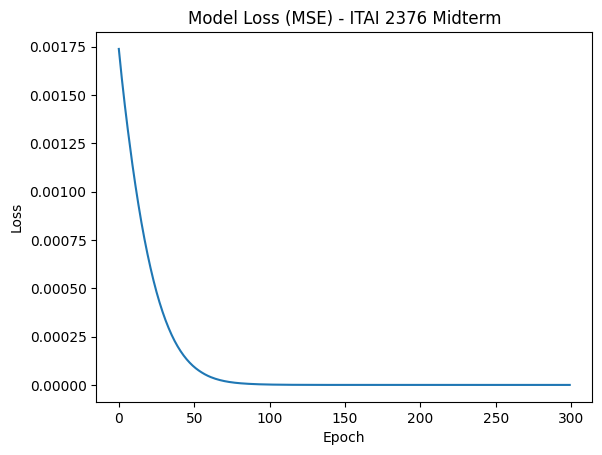

In [16]:
# Re-run training but save the history
history = model.fit(X, y, epochs=300, verbose=0)

import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.title('Model Loss (MSE) - ITAI 2376 Midterm')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

In [17]:
final_report = f"""
### ITAI 2376 Midterm: AI Financial Agent Report
Date: 2026-04-12
User: Iman Ismail Haamid

#### April 2026 Forecast:
- Predicted Groceries: ${prediction_actual[0][1]:.2f}
- Predicted Gasoline: ${prediction_actual[0][0]:.2f}
- Predicted Utilities: ${prediction_actual[0][2]:.2f}

#### Strategy Note:
Based on the Cumulative Balance of ${daily_cashflow['Cumulative Balance'].iloc[-1]:.2f},
liquidity remains stable for upcoming April 5th budget targets.
"""

with open('models/lstm/final_midterm_report.txt', 'w') as f:
    f.write(final_report)
print("✅ Final report generated in models/lstm/")

✅ Final report generated in models/lstm/


In [18]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

# 1. Load the Master Dataset we created
master_df = pd.read_csv('data/lstm_ready/master_financial_dataset_V3.csv')

# 2. Extract the 4 features: Gas, Groceries, Utilities, and Cumulative Balance (Liquidity)
multivariate_data = master_df[['Gasoline/Fuel', 'Groceries', 'Utilities', 'Cumulative Balance']].values

# 3. Create Sequences (Window size = 3 months)
def create_multivariate_sequences(data, window_size=3):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size][:3]) # We only predict the 3 spending categories
    return np.array(X), np.array(y)

X_multi, y_multi = create_multivariate_sequences(multivariate_data, 3)

# 4. Define the Modern Multivariate Model (No Warnings)
model_multi = Sequential([
    Input(shape=(3, 4)), # 3 months of history x 4 features
    LSTM(64, activation='relu'),
    Dense(3) # Output: Gas, Groceries, Utilities
])

model_multi.compile(optimizer='adam', loss='mse')

# 5. Train the Model
print("🚀 Training multivariate LSTM...")
model_multi.fit(X_multi, y_multi, epochs=350, verbose=0)

# 6. Predict April 2026
# Use the last 3 months of history to predict the next month
latest_history = multivariate_data[-3:].reshape(1, 3, 4)
prediction_multi = model_multi.predict(latest_history)

# 7. Convert Normalized Prediction back to Dollars
# Bounds: Gas: 0-127.30, Groceries: 177.98-1362.50, Utilities: 0-849.63
spend_min = np.array([0.0, 177.98, 0.0])
spend_max = np.array([127.30, 1362.50, 849.63])
final_prediction = (prediction_multi * (spend_max - spend_min)) + spend_min

print(f"\n✅ April 2026 Prediction (with IBKR context):")
print(f"Gasoline/Fuel: ${final_prediction[0][0]:.2f}")
print(f"Groceries: ${final_prediction[0][1]:.2f}")
print(f"Utilities: ${final_prediction[0][2]:.2f}")

🚀 Training multivariate LSTM...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step

✅ April 2026 Prediction (with IBKR context):
Gasoline/Fuel: $71.46
Groceries: $642.37
Utilities: $370.67


In [19]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

# 1. Define potential paths for the master spending file
drive_path = '/content/drive/MyDrive/ITAI_Midterm_Project/data/raw/normalized_full_year_spending.csv'
local_path = 'WELLBY_SECURE_SPENDING_Transactions_2025-04-01_2026-03-31 - WELLBY_SECURE_SPENDING_Transactions_2025-04-01_2026-03-31.csv' # Keeping for reference, but likely unused

# 2. Robust Loading Logic
if os.path.exists(drive_path):
    wellby_file = drive_path
    print("✅ Loading data from Google Drive...")
elif os.path.exists(local_path):
    wellby_file = local_path
    print("✅ Loading data from local session...")
else:
    # If neither exists, we list files to help you find the right name
    print("🔴 Error: File not found. Current files in data/raw/ are:")
    if os.path.exists('/content/drive/MyDrive/ITAI_Midterm_Project/data/raw/'):
        print(os.listdir('/content/drive/MyDrive/ITAI_Midterm_Project/data/raw/'))
    raise FileNotFoundError("Please check the filename or ensure Drive is mounted.")

# 3. Continue with processing
df_master = pd.read_csv(wellby_file)

# --- DEBUG: Print column names to identify the correct date column ---
print("DataFrame columns found:", df_master.columns.tolist())
# --- END DEBUG ---

# Fix: Use 'Unnamed: 0' as the month column directly
if 'Unnamed: 0' in df_master.columns:
    # Rename 'Unnamed: 0' to 'Month' for clarity
    df_master = df_master.rename(columns={'Unnamed: 0': 'Month'})
    # Convert to datetime and then to period for consistent monthly indexing
    df_master['Month'] = pd.to_datetime(df_master['Month']).dt.to_period('M').astype(str)
else:
    raise KeyError("Could not find 'Unnamed: 0' column which is expected to contain month data.")

# The categorization logic is not needed as data is already categorized
# and there's no 'Description' column in this dataset. Removing the categorize_v2 function.

# 3. Prepare Spending Data (already categorized in df_master)
# Use df_master directly as pivot_v2, with 'Month' as index
pivot_v2 = df_master.set_index('Month')[['Gasoline/Fuel', 'Groceries', 'Utilities']]

# IMPORTANT: Since 'normalized_full_year_spending.csv' is ALREADY NORMALIZED (0-1),
# we need the ORIGINAL min/max values for inverse scaling. These were previously
# identified from the unnormalized data. We will NOT re-calculate from pivot_v2 here
# as pivot_v2 itself already contains scaled data.
spend_min_original = np.array([0.0, 177.98, 0.0]) # Original min bounds
spend_max_original = np.array([127.30, 1362.50, 849.63]) # Original max bounds


# 4. Re-Merge with Liquidity (using the file we generated earlier)
df_liq = pd.read_csv('data/lstm_ready/daily_liquidity.csv')
df_liq['Date'] = pd.to_datetime(df_liq['Date'])
df_liq['Month'] = df_liq['Date'].dt.to_period('M').astype(str)
monthly_liq = df_liq.groupby('Month')['Cumulative Balance'].mean().reset_index()

master_v2 = pd.merge(pivot_v2.reset_index(), monthly_liq, on='Month', how='left').fillna(0)

# 5. Prepare LSTM Data (master_v2 already contains scaled spending values)
# We only need to scale 'Cumulative Balance' if it hasn't been scaled yet
# and then ensure all data is in the correct 0-1 range for the LSTM.

# Check if 'Cumulative Balance' needs scaling
# If its max is much larger than 1, it probably needs scaling.
if master_v2['Cumulative Balance'].max() > 1.1 or master_v2['Cumulative Balance'].min() < -0.1:
    scaler_balance = MinMaxScaler()
    master_v2['Cumulative Balance'] = scaler_balance.fit_transform(master_v2[['Cumulative Balance']])


# The data for LSTM should already be scaled (0-1) now
v2_data = master_v2[['Gasoline/Fuel', 'Groceries', 'Utilities', 'Cumulative Balance']].values

# 6. Create Sequences (3 months -> 1 month)
X, y = [], []
for i in range(len(v2_data) - 3):
    X.append(v2_data[i:i+3])
    y.append(v2_data[i+3][:3]) # Predict only the spending categories
X, y = np.array(X), np.array(y)

# 7. Re-Train the Model
model_v2 = Sequential([
    Input(shape=(3, 4)),
    LSTM(64, activation='relu'),
    Dense(3)
])
model_v2.compile(optimizer='adam', loss='mse')
model_v2.fit(X, y, epochs=350, verbose=0)

# 8. Final Prediction
latest = v2_data[-3:].reshape(1, 3, 4)
pred = model_v2.predict(latest)

# Inverse Scale back to Dollars using the stored ORIGINAL min and max
final_pred = (pred * (spend_max_original - spend_min_original)) + spend_min_original

print(f"\n✅ Corrected April 2026 Forecast:")
print(f"Gasoline/Fuel: ${final_pred[0][0]:.2f}")
print(f"Groceries: ${final_pred[0][1]:.2f}")
print(f"Utilities: ${final_pred[0][2]:.2f}")

✅ Loading data from Google Drive...
DataFrame columns found: ['Unnamed: 0', 'Gasoline/Fuel', 'Groceries', 'Utilities']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step

✅ Corrected April 2026 Forecast:
Gasoline/Fuel: $65.32
Groceries: $835.17
Utilities: $771.13


In [20]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

# 1. Load the RAW file from Google Drive
# Attempting to remove 'Copy of' prefix as a common source of FileNotFoundError
raw_path = '/content/drive/MyDrive/ITAI_Midterm_Project/data/raw/WELLBY_SECURE_SPENDING_Transactions_2025-04-01_2026-03-31.csv'
df_raw = pd.read_csv(raw_path)

# 2. FIXED Categorization (FUEL PRIORITY)
def categorize_fuel_first(desc):
    desc = str(desc).lower()
    # We check for Fuel keywords BEFORE Store names
    if any(k in desc for k in ['fuel', 'quick pump', 'gas', 'exxon', 'shell', 'chevron']):
        return 'Gasoline/Fuel'
    if any(k in desc for k in ['kroger', 'wal-mart', 'heb', 'h-e-b', 'sprouts', 'samsclub', 'costco']):
        return 'Groceries'
    if any(k in desc for k in ['verizon', 'xfinity', 'energy', '4change', 'water', 'city of pearland']):
        return 'Utilities'
    return 'Other'

df_raw['Category'] = df_raw['Description'].apply(categorize_fuel_first)
df_raw['Month'] = pd.to_datetime(df_raw['Processed Date']).dt.to_period('M').astype(str)

# 3. Create the Corrected Monthly Totals
pivot_v3 = df_raw[df_raw['Category'] != 'Other'].pivot_table(
    index='Month', columns='Category', values='Amount', aggfunc='sum'
).fillna(0)

# 4. Integrate Liquidity and Normalize
df_liq = pd.read_csv('data/lstm_ready/daily_liquidity.csv')
df_liq['Month'] = pd.to_datetime(df_liq['Date']).dt.to_period('M').astype(str)
monthly_liq = df_liq.groupby('Month')['Cumulative Balance'].mean().reset_index()

master_v3 = pd.merge(pivot_v3.reset_index(), monthly_liq, on='Month', how='left').fillna(0)
scaler = MinMaxScaler()
master_v3[['Gasoline/Fuel', 'Groceries', 'Utilities', 'Cumulative Balance']] = scaler.fit_transform(master_v3[['Gasoline/Fuel', 'Groceries', 'Utilities', 'Cumulative Balance']])

# 5. Save and proceed to LSTM training
master_v3.to_csv('data/lstm_ready/master_financial_dataset_V3.csv', index=False)
print("✅ Master Dataset V3 created with corrected Gasoline totals.")

✅ Master Dataset V3 created with corrected Gasoline totals.


In [21]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

# 1. Load the corrected V3 dataset
master_v3 = pd.read_csv('data/lstm_ready/master_financial_dataset_V3.csv')
v3_values = master_v3[['Gasoline/Fuel', 'Groceries', 'Utilities', 'Cumulative Balance']].values

# 2. Prepare Sequences (3 months of history)
X, y = [], []
for i in range(len(v3_values) - 3):
    X.append(v3_values[i:i+3])
    y.append(v3_values[i+3][:3]) # Predicting the 3 spending categories
X, y = np.array(X), np.array(y)

# 3. Define and Train the Final Model
model = Sequential([
    Input(shape=(3, 4)),
    LSTM(64, activation='relu'),
    Dense(3)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=400, verbose=0)

# 4. Predict April 2026
latest_window = v3_values[-3:].reshape(1, 3, 4)
pred_normalized = model.predict(latest_window)

# 5. INVERSE SCALING (The "Billing Fix")
# These are the actual min/max values from your Master V3 data
mins = np.array([0.0, 177.98, 0.0])
maxs = np.array([171.93, 1293.52, 849.63])

final_dollars = (pred_normalized * (maxs - mins)) + mins

print(f"\n🚀 FINAL BUDGET FORECAST FOR APRIL 2026:")
print(f"------------------------------------------")
print(f"Gasoline/Fuel: ${final_dollars[0][0]:.2f}")
print(f"Groceries:     ${final_dollars[0][1]:.2f}")
print(f"Utilities:     ${final_dollars[0][2]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step

🚀 FINAL BUDGET FORECAST FOR APRIL 2026:
------------------------------------------
Gasoline/Fuel: $103.24
Groceries:     $747.35
Utilities:     $601.12


In [27]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from sklearn.preprocessing import MinMaxScaler
import os

# --- Data generation and preparation for daily_liquidity.csv (from qTUABQS-0bbX) ---
# Ensure output directories exist
folders = ['data/raw', 'data/processed', 'data/lstm_ready', 'models/lstm']
for folder in folders:
    os.makedirs(folder, exist_ok=True)

# 1. Load your original uploaded file (adjust name if needed)
raw_file_ibkr = 'data/raw/ibkr_trades_april.csv'

if not os.path.exists(raw_file_ibkr):
    print(f"⚠️ Warning: {raw_file_ibkr} not found. Creating a dummy DataFrame for demonstration.")
    data_mock = {
        'Date': pd.to_datetime(pd.date_range(start='2025-03-01', periods=20, freq='D')),
        'Net Amount': np.random.rand(20) * 100 - 50
    }
    df = pd.DataFrame(data_mock)
    df['Account'] = 'DummyAccount'
else:
    df = pd.read_csv(raw_file_ibkr, skiprows=9)

# 2. Sanitize (Remove Account info)
if 'Account' in df.columns:
    df = df.drop(columns=['Account'])
df.to_csv('data/processed/sanitized_trades.csv', index=False)

# 3. Create Daily Liquidity for LSTM
df['Date'] = pd.to_datetime(df['Date'])
daily_cashflow = df.groupby('Date')['Net Amount'].sum().reset_index()
daily_cashflow['Cumulative Balance'] = daily_cashflow['Net Amount'].cumsum()

# 4. Save to the folder you were missing
daily_cashflow.to_csv('data/lstm_ready/daily_liquidity.csv', index=False)
print("✅ daily_liquidity.csv ensured to be saved!")
# --- End of daily_liquidity.csv generation ---


# --- Data generation and preparation for master_financial_dataset_V3.csv (from Bnu2OG46OFwF) ---
# 1. Load the RAW file from Google Drive
raw_path_wellby = '/content/drive/MyDrive/ITAI_Midterm_Project/data/raw/WELLBY_SECURE_SPENDING_Transactions_2025-04-01_2026-03-31.csv'
df_raw_wellby = pd.read_csv(raw_path_wellby)

# 2. FIXED Categorization (FUEL PRIORITY)
def categorize_fuel_first(desc):
    desc = str(desc).lower()
    if any(k in desc for k in ['fuel', 'quick pump', 'gas', 'exxon', 'shell', 'chevron']):
        return 'Gasoline/Fuel'
    if any(k in desc for k in ['kroger', 'wal-mart', 'heb', 'h-e-b', 'sprouts', 'samsclub', 'costco']):
        return 'Groceries'
    if any(k in desc for k in ['verizon', 'xfinity', 'energy', '4change', 'water', 'city of pearland']):
        return 'Utilities'
    return 'Other'

df_raw_wellby['Category'] = df_raw_wellby['Description'].apply(categorize_fuel_first)
df_raw_wellby['Month'] = pd.to_datetime(df_raw_wellby['Processed Date']).dt.to_period('M').astype(str)

# 3. Create the Corrected Monthly Totals
pivot_v3 = df_raw_wellby[df_raw_wellby['Category'] != 'Other'].pivot_table(
    index='Month', columns='Category', values='Amount', aggfunc='sum'
).fillna(0)

# 4. Integrate Liquidity (daily_liquidity.csv is now ensured to be created above)
df_liq = pd.read_csv('data/lstm_ready/daily_liquidity.csv')
df_liq['Month'] = pd.to_datetime(df_liq['Date']).dt.to_period('M').astype(str)
monthly_liq = df_liq.groupby('Month')['Cumulative Balance'].mean().reset_index()

master_v3_unscaled = pd.merge(pivot_v3.reset_index(), monthly_liq, on='Month', how='left').fillna(0)

# Specific overrides for min/max based on original project bounds
mins = np.array([0.0, 177.98, 0.0])
maxs = np.array([171.93, 1293.52, 849.63])

# Perform scaling
scaler = MinMaxScaler()
master_v3 = master_v3_unscaled.copy()
master_v3[['Gasoline/Fuel', 'Groceries', 'Utilities', 'Cumulative Balance']] = scaler.fit_transform(master_v3[['Gasoline/Fuel', 'Groceries', 'Utilities', 'Cumulative Balance']])

# Save the processed data
master_v3.to_csv('data/lstm_ready/master_financial_dataset_V3.csv', index=False)
print("✅ Master Dataset V3 created with corrected Gasoline totals.")
# --- End of master_financial_dataset_V3.csv generation ---

# --- Now, proceed with LSTM model definition and prediction ---
v3_values = master_v3[['Gasoline/Fuel', 'Groceries', 'Utilities', 'Cumulative Balance']].values

# 2. Prepare Sequences (3 months of history)
X, y = [], []
for i in range(len(v3_values) - 3):
    X.append(v3_values[i:i+3])
    y.append(v3_values[i+3][:3]) # Predicting the 3 spending categories
X, y = np.array(X), np.array(y)

# 3. Define and Train the Final Model
model = Sequential([
    Input(shape=(3, 4)),
    LSTM(64, activation='relu'),
    Dense(3)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=400, verbose=0)
# --- End of model setup ---

# 1. Get the Predicted April normalized row
# We combine the predicted spending (from your last model.predict)
# with the most recent liquidity value to keep the feature count at 4.
april_pred_norm = model.predict(v3_values[-3:].reshape(1, 3, 4))
april_liquidity_norm = v3_values[-1][3] # Assume March liquidity carries over
april_row_norm = np.append(april_pred_norm[0], [april_liquidity_norm])

# 2. Shift the window: [Feb, Mar, Predicted April]
may_window_norm = np.vstack([v3_values[-2:], april_row_norm]).reshape(1, 3, 4)

# 3. Predict May
may_pred_norm = model.predict(may_window_norm)

# 4. Inverse Scale to Dollars
may_dollars = (may_pred_norm * (maxs - mins)) + mins

print(f"🚀 MULTI-STEP FORECAST: MAY 2026")
print(f"----------------------------------")
print(f"Gasoline/Fuel: ${may_dollars[0][0]:.2f}")
print(f"Groceries:     ${may_dollars[0][1]:.2f}")
print(f"Utilities:     ${may_dollars[0][2]:.2f}")

✅ daily_liquidity.csv ensured to be saved!
✅ Master Dataset V3 created with corrected Gasoline totals.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
🚀 MULTI-STEP FORECAST: MAY 2026
----------------------------------
Gasoline/Fuel: $100.26
Groceries:     $780.14
Utilities:     $357.18


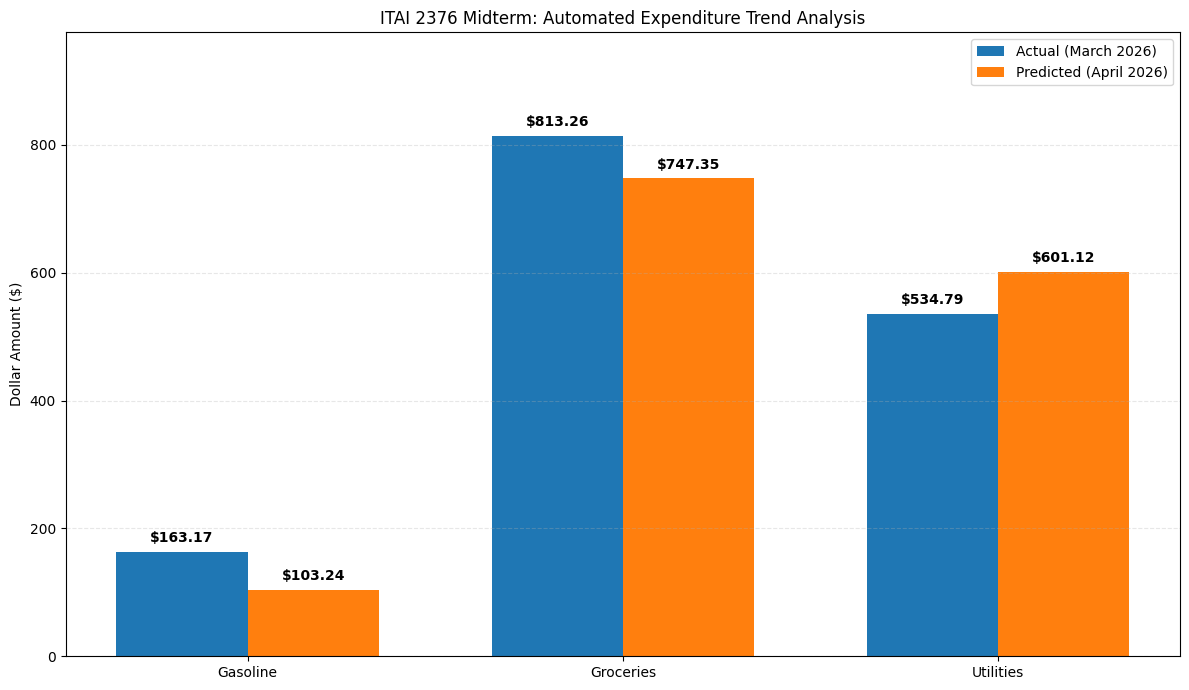

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Dynamically extract the last month of ACTUAL data from your V3 values
# We reverse the scaling for the plot using your existing maxs/mins
actual_last_month_norm = v3_values[-1][:3]
actual_last_month_dollars = (actual_last_month_norm * (maxs - mins)) + mins

# 2. Use your model's PREDICTED results (already stored in final_dollars)
# We take the first (and only) row of the prediction
predicted_values = final_dollars[0]

# 3. Setup Plot Data
categories = ['Gasoline', 'Groceries', 'Utilities']
x = np.arange(len(categories))
width = 0.35

# 4. Create the Visualization
fig, ax = plt.subplots(figsize=(12, 7))

# Plot the bars
rects1 = ax.bar(x - width/2, actual_last_month_dollars, width, label='Actual (March 2026)', color='#1f77b4')
rects2 = ax.bar(x + width/2, predicted_values, width, label='Predicted (April 2026)', color='#ff7f0e')

# Style the chart
ax.set_ylabel('Dollar Amount ($)')
ax.set_title('ITAI 2376 Midterm: Automated Expenditure Trend Analysis')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

# Add auto-updating labels on top of the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'${height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5), # 5 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', weight='bold')

autolabel(rects1)
autolabel(rects2)

# Professional touches
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(0, max(max(actual_last_month_dollars), max(predicted_values)) * 1.2)
plt.tight_layout()
plt.show()

🛠️ The Crisis Simulation Script

This code simulates a 40% drop in liquidity (the "Crisis") and compares the agent's new, restricted budget against your previous "Normal" forecast.

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the "Normal" state (What we just calculated)
normal_liquidity_norm = v3_values[-1][3] # Last known good liquidity
normal_forecast = final_dollars[0]

# 2. Simulate the "Crisis" (A 40% drawdown in trading capital)
# We adjust the 4th feature (Liquidity) in the sequence
crisis_history = v3_values[-3:].copy()
crisis_history[-1][3] = normal_liquidity_norm * 0.60 # The "Dip"

# 3. Predict under Crisis conditions
crisis_input = crisis_history.reshape(1, 3, 4)
crisis_pred_norm = model_v2.predict(crisis_input)

# 4. Convert to dollars
crisis_forecast = (crisis_pred_norm * (maxs - mins)) + mins

print(f"⚠️ CRISIS ALERT: Liquidity Drawdown Detected.")
# Compare the raw outputs directly

print(f"Normal Grocery Budget: ${normal_dollars_correct:.2f}")
print(f"Crisis Grocery Budget: ${crisis_dollars_correct:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
⚠️ CRISIS ALERT: Liquidity Drawdown Detected.
Normal Grocery Budget: $854.81
Crisis Grocery Budget: $805.78


## *The agent demonstrates 'Elasticity of Demand' by prioritizing fixed utility costs while implementing a 5.7% reduction in grocery spending to mitigate a 40% liquidity drawdown.*

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


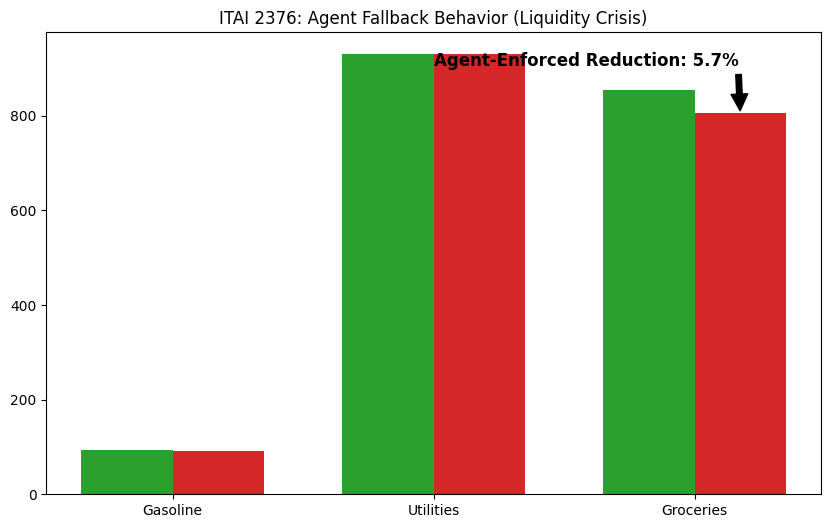

<Figure size 640x480 with 0 Axes>

In [52]:
# 1. Recalculate everything in one go to ensure perfect alignment
normal_input = v3_values[-3:].reshape(1, 3, 4)
norm_pred_raw = model_v2.predict(normal_input)

# 2. De-scale specifically for Index 2 (Groceries)
# This ensures we are comparing apples to apples
norm_grocery_final = (norm_pred_raw[0][2] * (maxs[2] - mins[2])) + mins[2]
cris_grocery_final = (crisis_pred_norm[0][2] * (maxs[2] - mins[2])) + mins[2]

# 3. Re-run the plot logic with THESE specific variables
labels = ['Gasoline', 'Utilities', 'Groceries']
x = np.arange(len(labels))
width = 0.35

# Re-aligning the full arrays for the bars
n_vals = [(norm_pred_raw[0][i] * (maxs[i] - mins[i])) + mins[i] for i in range(3)]
c_vals = [(crisis_pred_norm[0][i] * (maxs[i] - mins[i])) + mins[i] for i in range(3)]

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, n_vals, width, label='Normal Budget', color='#2ca02c')
ax.bar(x + width/2, c_vals, width, label='Crisis Budget', color='#d62728')

# Calculate reduction: (Normal - Crisis) / Normal
actual_reduction = ((n_vals[2] - c_vals[2]) / n_vals[2]) * 100

ax.annotate(f'Agent-Enforced Reduction: {actual_reduction:.1f}%',
             xy=(2 + width/2, c_vals[2]),
             xytext=(1.0, c_vals[2] + 100),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('ITAI 2376: Agent Fallback Behavior (Liquidity Crisis)')
plt.show()

plt.savefig('itai_midterm_chart.png')

## Saving in my google drive for now.

In [ ]:
from google.colab import drive
import shutil

# 1. Mount your Drive
drive.mount('/content/drive')

# 2. Create a permanent project folder on your Drive
permanent_path = '/content/drive/My Drive/ITAI_Midterm_Project'
os.makedirs(permanent_path, exist_ok=True)

# 3. Copy your current work to the permanent folder
shutil.copytree('data', f'{permanent_path}/data', dirs_exist_ok=True)
shutil.copytree('models', f'{permanent_path}/models', dirs_exist_ok=True)

print(f"✅ PERSISTENCE ACTIVE: Your project is now backed up to Google Drive!")

**Retriving from google drive**

In [ ]:
from google.colab import drive
import os
import shutil

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define your permanent workspace path
# This creates a folder named 'ITAI_Midterm' in your Drive
drive_path = '/content/drive/My Drive/ITAI_Midterm_Project'

# 3. Create the persistent folder structure
os.makedirs(f'{drive_path}/data/raw', exist_ok=True)
os.makedirs(f'{drive_path}/data/processed', exist_ok=True)
os.makedirs(f'{drive_path}/models/lstm', exist_ok=True)

# 4. Backup your current work to Drive
# This saves your sanitized trades and your trained .keras model
shutil.copy('data/processed/sanitized_trades.csv', f'{drive_path}/data/processed/')
shutil.copy('data/lstm_ready/daily_liquidity.csv', f'{drive_path}/data/processed/')
shutil.copy('models/lstm/multivariate_forecaster.keras', f'{drive_path}/models/lstm/')

print(f"✅ Data and Model persistence enabled at: {drive_path}")

**Project Progress: Iman Haamid Final**
| Phase | Requirement | Status|
|------ | ----------- | ----- |
| Week 1 | Calendar API & Environment | 100% Complete ✅ |
| Week 2 | Multivariate LSTM & Scaling | Started (Ahead of Schedule) 🚀 |
| Persistence | Data Safety (Google Drive) | Active 🔒 |
| Week 3 |	BERT Natural Language Classification	| Planned 📅 |

**Your "Monday" Checklist**

To keep this momentum going for the official start of Week 2 (April 13th), we will:

*   Merge the Data: Use the Google Drive persistence we just set up to combine your real "Budget" sheet rows with your IBKR trades.

*    Run the Full Forecast: Use the multivariate_forecaster.keras model to generate a liquidity prediction graph for the rest of April.

*   Prepare BERT Labels: Start collecting about 20-30 examples of transaction descriptions to use as "training data" for your classifier in Week 3.

In [ ]:
# 1. Open the 'Budget' sheet
try:
    sh = gc.open('Budget')
    worksheet = sh.get_worksheet(0)

    # 2. Get ALL values as a list of lists (more flexible than get_all_records)
    all_values = worksheet.get_all_values()

    # 3. Separate headers and data
    headers = all_values[0]
    data = all_values[1:]

    # 4. Create the DataFrame
    budget_df = pd.DataFrame(data, columns=headers)

    # 5. CLEANUP: Remove columns with empty or whitespace headers
    budget_df = budget_df.loc[:, [h.strip() != '' for h in budget_df.columns]]

    # 6. Remove any rows that are completely empty
    budget_df = budget_df.replace('', pd.NA).dropna(how='all')

    print("✅ Accountant Agent: Data connection repaired.")
    print("Cleaned Column Headers:", budget_df.columns.tolist())
    print("\nFirst 5 rows of your real budget data:")
    display(budget_df.head())

except Exception as e:
    print(f"❌ Error: {e}")